In [104]:
import pandas as pd
import re
from sentence_transformers import SentenceTransformer, util

# =========================================================
# 1. LOAD DATA
# =========================================================

df = pd.read_csv("clean_jobs_with_skills.csv")
taxonomy_df = pd.read_csv("skill_taxonomy.csv")


# =========================================================
# 2. CLEAN SKILL TEXT
# =========================================================

def clean_skill(text):
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z0-9+#]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# =========================================================
# 3. CREATE SKILL + ALIAS LOOKUP
# =========================================================

skill_lookup = {}

for _, row in taxonomy_df.iterrows():

    canonical = str(row["skill"]).strip()

    if not canonical or canonical.lower() == "nan":
        continue

    # Main skill
    skill_lookup[clean_skill(canonical)] = canonical

    # Aliases
    aliases = str(row.get("aliases", ""))

    if aliases.lower() != "nan":

        for alias in aliases.split("|"):

            alias = alias.strip()

            if alias:
                skill_lookup[clean_skill(alias)] = canonical


# Extra common aliases
extra_aliases = {
    "python3": "Python",
    "python 3": "Python",
    "python programming": "Python",
    "powerbi": "Power BI",
    "power bi": "Power BI",
    "power-bi": "Power BI",
    "postgres": "PostgreSQL",
    "postgresql": "PostgreSQL",
    "amazon web services": "AWS",
    "google cloud": "GCP",
    "ml": "Machine Learning",
    "machine learning": "Machine Learning",
    "nlp": "Natural Language Processing",
    "natural language processing": "Natural Language Processing",
    "sklearn": "Scikit-learn",
    "scikit learn": "Scikit-learn",
    "scikit-learn": "Scikit-learn"
}

for alias, canonical in extra_aliases.items():
    skill_lookup[clean_skill(alias)] = canonical


canonical_skills = sorted(set(skill_lookup.values()))


# =========================================================
# 4. LOAD TRANSFORMER MODEL
# =========================================================

model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

skill_embeddings = model.encode(
    canonical_skills,
    batch_size=32,
    convert_to_tensor=True,
    normalize_embeddings=True,
    show_progress_bar=True
)


# =========================================================
# 5. SENTENCE SPLITTER
# =========================================================

def split_into_sentences(text):

    if pd.isna(text):
        return []

    text = str(text)

    sentences = re.split(
        r'(?<=[.!?])\s+|\n+',
        text
    )

    return [
        s.strip()
        for s in sentences
        if s.strip()
    ]


# =========================================================
# 6. EXPLICIT SKILL + ALIAS EXTRACTION
# =========================================================

def extract_explicit_skills(text):

    if pd.isna(text):
        return []

    text_clean = clean_skill(text)

    found = []

    # Longest aliases first
    sorted_aliases = sorted(
        skill_lookup.keys(),
        key=len,
        reverse=True
    )

    for alias in sorted_aliases:

        pattern = (
            r'(?<!\w)'
            + re.escape(alias)
            + r'(?!\w)'
        )

        if re.search(pattern, text_clean):

            canonical = skill_lookup[alias]

            found.append(canonical)

    return list(dict.fromkeys(found))


# =========================================================
# 7. FINAL TRANSFORMER SKILL EXTRACTION
# =========================================================

def transformer_extract_skills(
    text,
    threshold=0.40,
    top_k=5
):

    if pd.isna(text):
        return []

    text = str(text).strip()

    if not text:
        return []

    # First: exact skill / alias detection
    explicit_skills = extract_explicit_skills(text)

    # Split description into sentences
    sentences = split_into_sentences(text)

    if not sentences:
        return explicit_skills

    # Transformer sentence embeddings
    sentence_embeddings = model.encode(
        sentences,
        batch_size=16,
        convert_to_tensor=True,
        normalize_embeddings=True
    )

    # Similarity
    similarity_matrix = util.cos_sim(
        sentence_embeddings,
        skill_embeddings
    )

    transformer_skills = []

    for sentence_scores in similarity_matrix:

        top_indices = sentence_scores.argsort(
            descending=True
        )[:top_k]

        for idx in top_indices:

            score = float(sentence_scores[idx])

            if score >= threshold:

                skill = canonical_skills[int(idx)]

                # IMPORTANT:
                # Only keep transformer result if
                # skill/alias actually appears in text
                if skill in explicit_skills:

                    transformer_skills.append(skill)

    # Combine results
    final_skills = list(
        dict.fromkeys(
            explicit_skills + transformer_skills
        )
    )

    return final_skills


# =========================================================
# 8. RUN ON ALL 7996 JOBS
# =========================================================

transformer_results = []

total = len(df)

for i, text in enumerate(
    df["clean_description"].fillna("").astype(str)
):

    result = transformer_extract_skills(
        text,
        threshold=0.40,
        top_k=5
    )

    transformer_results.append(result)

    if (i + 1) % 100 == 0:
        print(f"{i + 1}/{total} completed")


# =========================================================
# 9. ADD COLUMN
# =========================================================

df["transformer_skills"] = transformer_results


# =========================================================
# 10. SAVE FINAL DATASET
# =========================================================

df.to_csv(
    "clean_jobs_with_skills.csv",
    index=False
)

print("\n===================================")
print("DAY 14 COMPLETED")
print("===================================")
print("Rows:", len(df))
print("New Column: transformer_skills")
print("File saved: clean_jobs_transformer.csv")
print("===================================")

Batches: 100%|██████████| 4/4 [00:01<00:00,  3.20it/s]


100/7996 completed
200/7996 completed
300/7996 completed
400/7996 completed
500/7996 completed
600/7996 completed
700/7996 completed
800/7996 completed
900/7996 completed
1000/7996 completed
1100/7996 completed
1200/7996 completed
1300/7996 completed
1400/7996 completed
1500/7996 completed
1600/7996 completed
1700/7996 completed
1800/7996 completed
1900/7996 completed
2000/7996 completed
2100/7996 completed
2200/7996 completed
2300/7996 completed
2400/7996 completed
2500/7996 completed
2600/7996 completed
2700/7996 completed
2800/7996 completed
2900/7996 completed
3000/7996 completed
3100/7996 completed
3200/7996 completed
3300/7996 completed
3400/7996 completed
3500/7996 completed
3600/7996 completed
3700/7996 completed
3800/7996 completed
3900/7996 completed
4000/7996 completed
4100/7996 completed
4200/7996 completed
4300/7996 completed
4400/7996 completed
4500/7996 completed
4600/7996 completed
4700/7996 completed
4800/7996 completed
4900/7996 completed
5000/7996 completed
5100/7996

In [ ]:
text = "Experience with Python, SQL and AWS."
print(transformer_extract_skills(text))

NameError: name 'transformer_skills' is not defined

In [105]:
print(df[[
    "jobtitle",
    "transformer_skills"
]].head(20).to_string(index=False))

                                                              jobtitle                                                                                                                                transformer_skills
                              Walkin Data Entry Operator (night Shift) [Basic Computer Knowledge, Customer Service, Data Collection, English Typing, Data Entry, Operations, Internet, English, Typing, Tamil, BPO, KPO]
                                    Work Based Onhome Based Part Time.                                                          [Basic Computer Knowledge, Data Collection, Data Processing, Data Entry, English, Tamil]
                                                Pl/sql Developer - SQL                                                                                                                                             [SQL]
                                Manager/ad/partner - Indirect Tax - CA                                                              

# DAY 15 — Model Evaluation 

In [24]:
import pandas as pd
import numpy as np
import re
import ast
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("clean_jobs_with_skills.csv")

print("Dataset Shape:", df.shape)


# ============================================================
# 2. LOAD SKILL TAXONOMY
# ============================================================

taxonomy_df = pd.read_csv("skill_taxonomy.csv")

Dataset Shape: (7996, 23)


In [2]:
def clean_skill(text):

    text = str(text).lower().strip()

    text = re.sub(
        r'[^a-z0-9+#.-]+',
        ' ',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    )

    return text.strip()


skill_lookup = {}

for _, row in taxonomy_df.iterrows():

    skill = str(row["skill"]).strip()

    if skill.lower() == "nan" or skill == "":
        continue

    # Main skill
    skill_lookup[
        clean_skill(skill)
    ] = skill

    # Aliases
    aliases = str(row["aliases"])

    if aliases.lower() != "nan":

        for alias in aliases.split("|"):

            alias = alias.strip()

            if alias:

                skill_lookup[
                    clean_skill(alias)
                ] = skill


canonical_skills = sorted(
    set(skill_lookup.values())
)

print(
    "Total Canonical Skills:",
    len(canonical_skills)
)


Total Canonical Skills: 100


# create actual skills

In [3]:

def extract_actual_skills(text):

    if pd.isna(text):
        return []

    text = str(text)

    match = re.search(
        r'key\s*skills?\s*(.*?)(?='
        r'desired candidate profile|'
        r'company profile|'
        r'salary|'
        r'industry|'
        r'functional area|'
        r'role category|'
        r'$)',
        text,
        flags=re.IGNORECASE | re.DOTALL
    )

    if not match:
        return []

    keyskills_text = clean_skill(
        match.group(1)
    )

    found_skills = []

    for alias, main_skill in skill_lookup.items():

        pattern = (
            r'(?<!\w)'
            + re.escape(alias)
            + r'(?!\w)'
        )

        if re.search(
            pattern,
            keyskills_text
        ):

            found_skills.append(
                main_skill
            )

    return list(
        dict.fromkeys(found_skills)
    )


df["actual_skills"] = df[
    "jobdescription"
].apply(
    extract_actual_skills
)

In [4]:
# ============================================================
# 5. REMOVE ROWS WITHOUT ACTUAL SKILLS
# ============================================================

df_eval = df[
    df["actual_skills"].apply(
        lambda x: len(x) > 0
    )
].copy()

df_eval.reset_index(
    drop=True,
    inplace=True
)

print(
    "Rows with actual skills:",
    len(df_eval)
)


Rows with actual skills: 2435


# train and test split

In [5]:

train_idx, test_idx = train_test_split(
    np.arange(len(df_eval)),
    test_size=0.20,
    random_state=42
)

train_df = df_eval.iloc[
    train_idx
].copy()

test_df = df_eval.iloc[
    test_idx
].copy()

print(
    "Training rows:",
    len(train_df)
)

print(
    "Testing rows:",
    len(test_df)
)

Training rows: 1948
Testing rows: 487


In [6]:
# Count skills in training data
skill_counts = {}

for skills in train_df["actual_skills"]:

    for skill in skills:

        skill_counts[skill] = (
            skill_counts.get(skill, 0) + 1
        )


In [7]:
# Keep skills having at least 2 training example
ml_skills_list = sorted(
    [
        skill
        for skill, count in skill_counts.items()
        if count >= 2
    ]
)

print(
    "Skills used by ML model:",
    len(ml_skills_list)
)

Skills used by ML model: 57


In [8]:
mlb = MultiLabelBinarizer(
    classes=ml_skills_list
)

y_train = mlb.fit_transform(
    train_df["actual_skills"].apply(
        lambda skills: [
            s for s in skills
            if s in ml_skills_list
        ]
    )
)



# TF-IDF features ml model

In [9]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(
    train_df["clean_description"].fillna("")
)

X_test = vectorizer.transform(
    test_df["clean_description"].fillna("")
)


print(
    "TF-IDF Training Shape:",
    X_train.shape
)

print(
    "TF-IDF Testing Shape:",
    X_test.shape
)

TF-IDF Training Shape: (1948, 20000)
TF-IDF Testing Shape: (487, 20000)


# trained ml skill

In [10]:

print("\nTraining ML Skill Extractor...")

ml_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),
    n_jobs=-1
)

ml_model.fit(
    X_train,
    y_train
)

print(
    "ML Skill Extractor trained successfully."
)

y_ml_pred = ml_model.predict(
    X_test
)


# Convert binary predictions → skill names

ml_predicted_skills = []

for row in y_ml_pred:

    skills = [
        skill
        for skill, value in zip(
            mlb.classes_,
            row
        )
        if value == 1
    ]

    ml_predicted_skills.append(
        skills
    )


test_df["ml_skills"] = (
    ml_predicted_skills
)



Training ML Skill Extractor...
ML Skill Extractor trained successfully.


# helper function

In [11]:
def to_set(value):

    if value is None:
        return set()

    if isinstance(
        value,
        float
    ) and pd.isna(value):

        return set()

    if isinstance(
        value,
        (list, tuple, set)
    ):

        return {
            str(x).strip().lower()
            for x in value
            if str(x).strip()
        }

    value = str(value).strip()

    if not value:
        return set()

    try:

        parsed = ast.literal_eval(
            value
        )

        if isinstance(
            parsed,
            (list, tuple, set)
        ):

            return {
                str(x).strip().lower()
                for x in parsed
                if str(x).strip()
            }

    except:

        pass

    return {
        value.lower()
    }

# evalution function

In [12]:
def evaluate_method(
    actual_column,
    predicted_column,
    method_name
):

    y_true = []
    y_pred = []

    for actual, predicted in zip(
        actual_column,
        predicted_column
    ):

        actual = {
            str(x).lower().strip()
            for x in actual
        }

        predicted = {
            str(x).lower().strip()
            for x in predicted
        }

        for skill in canonical_skills:

            skill_lower = skill.lower()

            y_true.append(
                1
                if skill_lower in actual
                else 0
            )

            y_pred.append(
                1
                if skill_lower in predicted
                else 0
            )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    tn, fp, fn, tp = cm.ravel()

    return {
        "Method": method_name,
        "Precision": round(
            precision, 4
        ),
        "Recall": round(
            recall, 4
        ),
        "F1_Score": round(
            f1, 4
        ),
        "Accuracy": round(
            accuracy, 4
        ),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
        "Confusion_Matrix": str(
            cm.tolist()
        )
    }


# evalution 

In [13]:
methods = {

    "Dictionary":
        "dictionary_skills",

    "Regex":
        "regex_Phrase_skills",

    "TF-IDF":
        "tfidf_keywords",

    "NER":
        "ner_skills",

    "ML Model":
        "ml_skills",

    "Transformer":
        "transformer_skills"
}


results = []


for method_name, column in methods.items():

    print(
        "\nEvaluating:",
        method_name
    )

    predictions = test_df[
        column
    ].apply(to_set)

    result = evaluate_method(
        test_df["actual_skills"],
        predictions,
        method_name
    )

    results.append(result)


Evaluating: Dictionary

Evaluating: Regex

Evaluating: TF-IDF

Evaluating: NER

Evaluating: ML Model

Evaluating: Transformer


# final model comparison

In [14]:
model_comparison = pd.DataFrame(
    results
)


print("\n")
print("=" * 100)
print("DAY 15 — FINAL MODEL COMPARISON")
print("=" * 100)

print(
    model_comparison[
        [
            "Method",
            "Precision",
            "Recall",
            "F1_Score",
            "Accuracy",
            "TP",
            "FP",
            "FN",
            "TN"
        ]
    ].to_string(index=False)
)




DAY 15 — FINAL MODEL COMPARISON
     Method  Precision  Recall  F1_Score  Accuracy  TP  FP  FN    TN
 Dictionary     0.4979  0.9350    0.6498    0.9812 848 855  59 46938
      Regex     0.4953  0.9350    0.6476    0.9810 848 864  59 46929
     TF-IDF     0.8880  0.3583    0.5106    0.9872 325  41 582 47752
        NER     0.5209  0.9327    0.6685    0.9828 846 778  61 47015
   ML Model     0.6342  0.7398    0.6830    0.9872 671 387 236 47406
Transformer     0.5166  0.9614    0.6721    0.9825 872 816  35 46977


# save model comparison

In [16]:
model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)



# saved result

In [17]:
test_df.to_csv(
    "day15_skill_results.csv",
    index=False
)

# save trained ml model

In [18]:
import joblib

joblib.dump(
    ml_model,
    "ml_skill_extractor.pkl"
)

joblib.dump(
    vectorizer,
    "ml_skill_vectorizer.pkl"
)

joblib.dump(
    mlb,
    "ml_skill_label_encoder.pkl"
)


['ml_skill_label_encoder.pkl']

# find best MODEL

In [19]:

best_model = model_comparison.loc[
    model_comparison[
        "F1_Score"
    ].idxmax()
]


print("\n")
print("=" * 100)
print("BEST MODEL")
print("=" * 100)

print(
    "Method    :",
    best_model["Method"]
)

print(
    "Precision :",
    best_model["Precision"]
)

print(
    "Recall    :",
    best_model["Recall"]
)

print(
    "F1 Score  :",
    best_model["F1_Score"]
)

print(
    "Accuracy  :",
    best_model["Accuracy"]
)




BEST MODEL
Method    : ML Model
Precision : 0.6342
Recall    : 0.7398
F1 Score  : 0.683
Accuracy  : 0.9872


# ============================================================
# 20. COMPLETION
# ============================================================

In [20]:
print("\n")
print("=" * 100)
print("DAY 15 COMPLETED SUCCESSFULLY")
print("=" * 100)

print("\nFiles created:")

print("1. model_comparison.csv")
print("2. day15_skill_results.csv")
print("3. ml_skill_extractor.pkl")
print("4. ml_skill_vectorizer.pkl")
print("5. ml_skill_label_encoder.pkl")



DAY 15 COMPLETED SUCCESSFULLY

Files created:
1. model_comparison.csv
2. day15_skill_results.csv
3. ml_skill_extractor.pkl
4. ml_skill_vectorizer.pkl
5. ml_skill_label_encoder.pkl


# confusion matrix 

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
for _, row in model_comparison.iterrows():

    method = row["Method"]

    # Confusion matrix string ko list mein convert karo
    cm = ast.literal_eval(
        row["Confusion_Matrix"]
    )

    # Convert to numpy array
    cm = np.array(cm)

    # Create figure
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Not Skill", "Skill"],
        yticklabels=["Not Skill", "Skill"]
    )

    plt.title(
        f"Confusion Matrix - {method}"
    )

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "Actual"
    )

    plt.tight_layout()

    plt.show()

NameError: name 'model_comparison' is not defined

# confusion matrix - best model

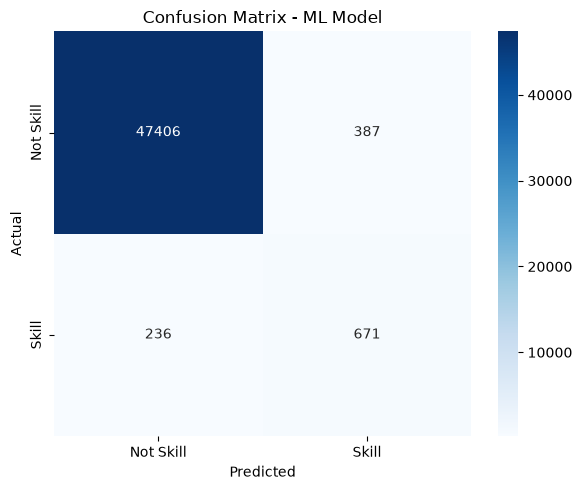

In [31]:
# ============================================================
# CONFUSION MATRIX — BEST MODEL (ML MODEL)
# ============================================================

best = model_comparison[
    model_comparison["Method"] == "ML Model"
].iloc[0]

cm = np.array(
    ast.literal_eval(
        best["Confusion_Matrix"]
    )
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Skill", "Skill"],
    yticklabels=["Not Skill", "Skill"]
)

plt.title(
    "Confusion Matrix - ML Model"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.tight_layout()

plt.show()

# day 16 error analysis

In [3]:
# ============================================================
# DAY 16 — FINAL ERROR ANALYSIS
# ============================================================

import pandas as pd
import ast
from difflib import SequenceMatcher


# ------------------------------------------------------------
# STEP 1 — Load Day 15 Results
# ------------------------------------------------------------

error_df = pd.read_csv("day15_skill_results.csv")

print("Day 15 Shape:", error_df.shape)


# ------------------------------------------------------------
# STEP 2 — Convert Skills into Lists
# ------------------------------------------------------------

def convert_to_list(value):

    if pd.isna(value):
        return []

    if isinstance(value, list):
        return value

    try:
        result = ast.literal_eval(str(value))

        if isinstance(result, list):
            return result

        return [str(result)]

    except:
        return [str(value)]


error_df["actual_skills"] = (
    error_df["actual_skills"]
    .apply(convert_to_list)
)

error_df["ml_skills"] = (
    error_df["ml_skills"]
    .apply(convert_to_list)
)


# ------------------------------------------------------------
# STEP 3 — Load Skill Taxonomy
# ------------------------------------------------------------

taxonomy_df = pd.read_csv(
    "skill_taxonomy.csv"
)

skill_map = {}

for _, row in taxonomy_df.iterrows():

    skill = str(row["skill"]).strip().lower()

    skill_map[skill] = skill

    aliases = str(row["aliases"]).split("|")

    for alias in aliases:

        alias = alias.strip().lower()

        if alias:
            skill_map[alias] = skill


# ------------------------------------------------------------
# STEP 4 — Normalize Skill
# ------------------------------------------------------------

def normalize_skill(skill):

    skill = str(skill).strip().lower()

    return skill_map.get(skill, skill)


# ------------------------------------------------------------
# STEP 5 — Similarity
# ------------------------------------------------------------

def similarity_score(a, b):

    return SequenceMatcher(
        None,
        str(a).lower(),
        str(b).lower()
    ).ratio()


# ------------------------------------------------------------
# STEP 6 — Find Best Matching Prediction
# ------------------------------------------------------------

def analyze_job(actual_list, predicted_list):

    results = []

    used_predictions = set()

    actual_list = [
        str(x).strip()
        for x in actual_list
        if str(x).strip()
    ]

    predicted_list = [
        str(x).strip()
        for x in predicted_list
        if str(x).strip()
    ]


    # --------------------------------------------
    # Match every actual skill with BEST prediction
    # --------------------------------------------

    for actual in actual_list:

        best_index = None
        best_score = 0

        for j, predicted in enumerate(predicted_list):

            if j in used_predictions:
                continue

            score = similarity_score(
                actual,
                predicted
            )

            if score > best_score:

                best_score = score
                best_index = j


        # ----------------------------------------
        # No prediction available
        # ----------------------------------------

        if best_index is None:

            results.append({
                "Actual": actual,
                "Predicted": "",
                "Error": "False Negative"
            })

            continue


        predicted = predicted_list[best_index]


        # ----------------------------------------
        # Exact Match
        # ----------------------------------------

        if (
            str(actual).strip().lower()
            ==
            str(predicted).strip().lower()
        ):

            used_predictions.add(best_index)

            continue


        # ----------------------------------------
        # Synonym Problem
        # ----------------------------------------

        if normalize_skill(actual) == normalize_skill(predicted):

            category = "Synonym Problem"


        # ----------------------------------------
        # Partial Entity
        # ----------------------------------------

        elif (
            str(actual).lower() in str(predicted).lower()
            or
            str(predicted).lower() in str(actual).lower()
        ):

            category = "Partial Entity"


        # ----------------------------------------
        # Spelling Problem
        # ----------------------------------------

        elif best_score >= 0.80:

            category = "Spelling Problem"


        # ----------------------------------------
        # Wrong Entity
        # ----------------------------------------

        else:

            category = "Wrong Entity"


        results.append({
            "Actual": actual,
            "Predicted": predicted,
            "Error": category
        })

        used_predictions.add(best_index)


    # ------------------------------------------------
    # Extra predictions
    # ------------------------------------------------

    for j, predicted in enumerate(predicted_list):

        if j not in used_predictions:

            predicted_lower = predicted.lower()

            if predicted_lower not in skill_map:

                category = "Unknown Skill"

            else:

                category = "False Positive"


            results.append({
                "Actual": "",
                "Predicted": predicted,
                "Error": category
            })


    return results


# ------------------------------------------------------------
# STEP 7 — Analyze Entire Test Dataset
# ------------------------------------------------------------

final_error_records = []


for i, row in error_df.iterrows():

    results = analyze_job(
        row["actual_skills"],
        row["ml_skills"]
    )


    for result in results:

        final_error_records.append({

            "Job_Index": i,

            "Job_Title": row["jobtitle"],

            "Actual": result["Actual"],

            "Predicted": result["Predicted"],

            "Error": result["Error"]
        })


# ------------------------------------------------------------
# STEP 8 — Create Final Error DataFrame
# ------------------------------------------------------------

final_error_analysis = pd.DataFrame(
    final_error_records
)


print("\nTotal Error Records:",
      len(final_error_analysis))


print("\nFirst 10 Errors:")

print(
    final_error_analysis.head(10)
)


# ------------------------------------------------------------
# STEP 9 — Remove Empty / Exact Matches
# ------------------------------------------------------------

final_error_analysis = final_error_analysis[
    final_error_analysis["Error"].notna()
].copy()


# ------------------------------------------------------------
# STEP 10 — Error Category Summary
# ------------------------------------------------------------

final_category_summary = (

    final_error_analysis["Error"]

    .value_counts()

    .reset_index()
)


final_category_summary.columns = [
    "Error_Type",
    "Count"
]


print("\n==========================================")
print("FINAL ERROR CATEGORIES")
print("==========================================")

print(final_category_summary)


# ------------------------------------------------------------
# STEP 11 — Save Excel Report
# ------------------------------------------------------------

with pd.ExcelWriter(
    "Error_Analysis_Report.xlsx",
    engine="openpyxl"
) as writer:

    final_error_analysis.to_excel(
        writer,
        sheet_name="Error_Analysis",
        index=False
    )

    final_category_summary.to_excel(
        writer,
        sheet_name="Error_Summary",
        index=False
    )


print("\n==========================================")
print("DAY 16 COMPLETED")
print("==========================================")

print(
    "File saved: Error_Analysis_Report.xlsx"
)

Day 15 Shape: (487, 25)

Total Error Records: 573

First 10 Errors:
   Job_Index                                          Job_Title  \
0          0                                   Teradata Analyst   
1          0                                   Teradata Analyst   
2          1       Account Manager / Client Servicing Executive   
3          2               User Experience Engineer Opportunity   
4          2               User Experience Engineer Opportunity   
5          3  Job Opening for Electrical Experience and Fres...   
6          5                CB - Business Analyst - Team Leader   
7          8  Quality Assurance Engineer/lead - Automation T...   
8          8  Quality Assurance Engineer/lead - Automation T...   
9         10                                     JAVA Developer   

             Actual   Predicted           Error  
0            Hadoop              False Negative  
1                           SQL  False Positive  
2                      Internet  False Posit

# day 17 skill normalization

In [167]:
print("Shape:", final_error_analysis.shape)

print("\nColumns:")
print(final_error_analysis.columns.tolist())

print("\nFirst 10 rows:")
print(
    final_error_analysis[
        ["Actual", "Predicted", "Error"]
    ].head(10)
)

Shape: (573, 5)

Columns:
['Job_Index', 'Job_Title', 'Actual', 'Predicted', 'Error']

First 10 rows:
             Actual   Predicted           Error
0            Hadoop              False Negative
1                           SQL  False Positive
2                      Internet  False Positive
3     Communication  JavaScript    Wrong Entity
4                           CSS  False Positive
5      Transformers              False Negative
6     Communication              False Negative
7  Customer Support           C  Partial Entity
8                          Java  False Positive
9                          HTML  False Positive


In [4]:
import pandas as pd
import re
import ast

In [5]:
df = pd.read_csv("clean_jobs_with_skills.csv")
print(df.shape)
print(df.columns.tolist())

(7996, 23)
['company', 'education', 'experience', 'industry', 'jobdescription', 'jobid', 'joblocation_address', 'jobtitle', 'numberofpositions', 'payrate', 'postdate', 'site_name', 'skills', 'uniq_id', 'clean_description', 'original_length', 'clean_length', 'dictionary_skills', 'regex_Phrase_skills', 'tfidf_keywords', 'ner_skills', 'ml_category', 'transformer_skills']


In [6]:
taxonomy = pd.read_csv("skill_taxonomy.csv")
print(taxonomy.head())
print(taxonomy.columns.tolist())

    skill     category          aliases
0  Python  Programming   python3|python
1    Java  Programming             java
2       C  Programming                c
3     C++  Programming  cpp|c plus plus
4      C#  Programming   csharp|c sharp
['skill', 'category', 'aliases']


# create normalization function

In [7]:
def clean_skill_text(skill):

    skill = str(skill).lower().strip()

    # Replace special characters with space
    skill = re.sub(r'[^a-z0-9+#]+', ' ', skill)

    # Remove extra spaces
    skill = re.sub(r'\s+', ' ', skill).strip()

    return skill

In [8]:
def compact_skill(skill):
    
    return clean_skill_text(skill).replace(" ", "")
    

In [9]:
print(clean_skill_text("Power-BI"))
print(compact_skill("Power-BI"))

print(clean_skill_text("Python 3"))
print(compact_skill("Python 3"))

power bi
powerbi
python 3
python3


In [51]:
skill_map = {}
compact_skill_map = {}

for _, row in taxonomy.iterrows():

    canonical = str(row["skill"]).strip()

    skill_map[clean_skill_text(canonical)] = canonical
    compact_skill_map[compact_skill(canonical)] = canonical

    aliases = str(row["aliases"])

    if aliases != "nan":
        for alias in aliases.split("|"):

            alias = alias.strip()

            if alias:
                skill_map[clean_skill_text(alias)] = canonical
                compact_skill_map[compact_skill(alias)] = canonical
                print("Taxonomy mapping created.")
print("Normal mappings:", len(skill_map))
print("Compact mappings:", len(compact_skill_map))

Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy mapping created.
Taxonomy map

In [21]:
manual_aliases = {

    "python 3": "Python",
    "python3": "Python",
    "python programming": "Python",

    "powerbi": "Power BI",
    "power bi": "Power BI",
    "power-bi": "Power BI",

    "postgres": "PostgreSQL",
    "postgresql": "PostgreSQL",

    "reactjs": "React",
    "react.js": "React",

    "nodejs": "Node.js",
    "node.js": "Node.js",

    "javascript": "JavaScript",
    "js": "JavaScript",

    "typescript": "TypeScript",
    "ts": "TypeScript"
}

for alias, canonical in manual_aliases.items():

    skill_map[clean_skill_text(alias)] = canonical
    compact_skill_map[compact_skill(alias)] = canonical

In [22]:
def normalize_skill(skill):
    
    if pd.isna(skill):
        return None
    
    original = str(skill).strip()
    
    if original == "":
        return None
    
    # Step 1: lowercase + special character cleaning
    cleaned = clean_skill_text(original)
    
    # Step 2: normal alias/canonical matching
    if cleaned in skill_map:
        return skill_map[cleaned]
    
    # Step 3: compact matching
    compact = compact_skill(original)
    
    if compact in compact_skill_map:
        return compact_skill_map[compact]
    
    # Unknown skill ko remove nahi karenge
    return original

In [36]:
test_skills = [
    "python",
    "Python3",
    "Python 3",
    "Python Programming",
    "PowerBI",
    "Power BI",
    "Power-BI",
    "Postgres"
]

print("NORMALIZATION TEST")
print("=" * 40)

for skill in test_skills:

    print(f"{skill:25} → {normalize_skill(skill)}")

NORMALIZATION TEST
python                    → Python
Python3                   → Python
Python 3                  → Python
Python Programming        → Python
PowerBI                   → Power BI
Power BI                  → Power BI
Power-BI                  → Power BI
Postgres                  → PostgreSQL


In [54]:
def convert_to_list(value):

    if value is None:
        return []

    if isinstance(value, float) and pd.isna(value):
        return []

    # Python list
    if isinstance(value, list):
        return value

    # NumPy array
    if hasattr(value, "tolist"):
        value = value.tolist()

        if isinstance(value, list):
            return value

    # String representation of list
    if isinstance(value, str):

        value = value.strip()

        if value == "":
            return []

        try:
            result = ast.literal_eval(value)

            if isinstance(result, list):
                return result

            return []

        except (ValueError, SyntaxError):
            return []

    return []

In [59]:
skill_columns = [
    "dictionary_skills",
    "regex_Phrase_skills",
    "ner_skills",
    "transformer_skills"
]

for col in skill_columns:
    
    normalized_col = "normalized_" + col
    
    df[normalized_col] = df[col].apply(
        lambda skills: list(dict.fromkeys(
            normalize_skill(skill)
            for skill in skills
            if normalize_skill(skill) is not None
        ))
    )

print("All normalized columns created successfully!")

print([
    col for col in df.columns
    if col.startswith("normalized_")
])

All normalized columns created successfully!
['normalized_transformer_skills', 'normalized_dictionary_skills', 'normalized_regex_Phrase_skills', 'normalized_ner_skills']


In [60]:
normalized_columns = [
    "normalized_dictionary_skills",
    "normalized_regex_Phrase_skills",
    "normalized_ner_skills",
    "normalized_transformer_skills"
]

df["normalized_skills"] = df[normalized_columns].apply(
    lambda row: list(dict.fromkeys(
        skill
        for skills in row
        for skill in skills
        if skill
    )),
    axis=1
)

In [62]:
df["normalized_skills"] = df[
    normalized_columns
].apply(
    lambda row: list(
        dict.fromkeys(
            skill
            for skills in row
            for skill in skills
            if skill
        )
    ),
    axis=1
)

print("Final normalized_skills column created.")

Final normalized_skills column created.


In [63]:
print(
    df[
        [
            "jobtitle",
            "normalized_skills"
        ]
    ].head(10).to_string()
)

                                                         jobtitle                                                                                                                                  normalized_skills
0                        Walkin Data Entry Operator (night Shift)  [Basic Computer Knowledge, Internet, Data Entry, Typing, English Typing, Data Collection, Customer Service, BPO, KPO, Operations, English, Tamil]
1                              Work Based Onhome Based Part Time.                                                           [Basic Computer Knowledge, Data Entry, Data Collection, Data Processing, English, Tamil]
2                                          Pl/sql Developer - SQL                                                                                                                                              [SQL]
3                          Manager/ad/partner - Indirect Tax - CA                                                                                   

In [64]:
df.to_csv(
    "clean_jobs_normalized.csv",
    index=False
)

print("File saved successfully!")
print("File: clean_jobs_normalized.csv")
print("Shape:", df.shape)

File saved successfully!
File: clean_jobs_normalized.csv
Shape: (7996, 28)


In [65]:
normalized_output = df[
    [
        "jobid",
        "jobtitle",
        "normalized_skills"
    ]
].copy()

normalized_output.to_csv(
    "normalized_skills.csv",
    index=False
)

print("Saved: normalized_skills.csv")
print("Shape:", normalized_output.shape)

Saved: normalized_skills.csv
Shape: (7996, 3)


In [66]:
check = pd.read_csv(
    "normalized_skills.csv"
)

print("Final Shape:", check.shape)

print("\nColumns:")
print(check.columns.tolist())

print("\nFirst 5 Rows:")
print(check.head())

Final Shape: (7996, 3)

Columns:
['jobid', 'jobtitle', 'normalized_skills']

First 5 Rows:
          jobid                                  jobtitle  \
0  210516002263  Walkin Data Entry Operator (night Shift)   
1  210516002391        Work Based Onhome Based Part Time.   
2  101016900534                    Pl/sql Developer - SQL   
3   81016900536    Manager/ad/partner - Indirect Tax - CA   
4  120916002122           JAVA Technical Lead (6-8 yrs) -   

                                   normalized_skills  
0  ['Basic Computer Knowledge', 'Internet', 'Data...  
1  ['Basic Computer Knowledge', 'Data Entry', 'Da...  
2                                            ['SQL']  
3                                              ['C']  
4  ['Java', 'JavaScript', 'HTML', 'Angular', 'MyS...  


In [68]:
validation_skills = [
    "python3",
    "python 3",
    "python programming",
    "powerbi",
    "power bi",
    "power-bi",
    "postgres"
]

print("DAY 17 NORMALIZATION TEST")
print("=" * 40)

for skill in validation_skills:
    result = normalize_skill(skill)

    print(
        f"{skill:25} → {result}"
    )
    # print(f"{skill:25} → {normalize_skill(skill)}")

DAY 17 NORMALIZATION TEST
python3                   → Python
python 3                  → Python
python programming        → python programming
powerbi                   → Power BI
power bi                  → Power BI
power-bi                  → Power BI
postgres                  → PostgreSQL


In [70]:
import os

if os.path.exists("normalized_skills.csv"):
    print("======================================")
    print("DAY 17 COMPLETED SUCCESSFULLY")
    print("======================================")
    print("File: normalized_skills.csv")
    print("Rows:", len(normalized_output))
    print("Columns:", len(normalized_output.columns))
else:
    print("File was not created.")

DAY 17 COMPLETED SUCCESSFULLY
File: normalized_skills.csv
Rows: 7996
Columns: 3
